<a href="https://colab.research.google.com/github/Andoniadou-Lab/consensus_pituitary_atlas/blob/main/Curation_assigning_sexes_to_samples.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## This notebook shows the workflow to correct sex metadata across samples as well as to assign sex metadata where it was missing

Install packages

In [ ]:
!pip install scanpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.6/58.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 100.7 MB/s eta 0:00:00


In [ ]:
import anndata
import scanpy as sc

In [ ]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
#load atlas source file
import pandas as pd
import numpy as np
np.random.seed(42)
df = pd.read_excel('/content/drive/MyDrive/pituitary_atlas/source_table/pituitary_atlas.xlsx')
pituitary_atlas = df.copy()
df = df[df['Modality'].isin(['sc','sn','multi_rna'])]
df.reset_index(drop=True, inplace=True)
df

,GEO,SRA_ID,Name,Conditions,Normal,Background,Sorted,Author,DOI,Age,...,filtering_junk,median_cellassign_prob,most_recent_workflow,n_cells,processed_atac,passed_qc_tcc,tcc_pseudobulked,Core,Notes 1,Notes 2
0,GSM4594333,SRX8489818,M-Pituitary,normal,1,C57BL/6,0,Ruf-Zamojski et al. (2021),10.1038/s41467-021-22859-w,10-12 weeks,...,1.0,1.000000,v_0.01,1278.0,0.0,1.0,v_0.01,1,NaN,NaN
1,GSM4594334,SRX8489819,FM_Pit_1-1,normal,1,C57BL/6,0,Ruf-Zamojski et al. (2021),10.1038/s41467-021-22859-w,10-12 weeks,...,1.0,1.000000,v_0.01,8236.0,0.0,1.0,v_0.01,1,NaN,NaN
2,GSM4594335,SRX8489820,FM_Pit_1-2,normal,1,C57BL/6,0,Ruf-Zamojski et al. (2021),10.1038/s41467-021-22859-w,10-12 weeks,...,1.0,1.000000,v_0.01,7092.0,0.0,1.0,v_0.01,1,NaN,NaN
3,GSM4594336,SRX8489821,MM_Pit_4-1,normal,1,C57BL/6,0,Ruf-Zamojski et al. (2021),10.1038/s41467-021-22859-w,10-12 weeks,...,1.0,1.000000,v_0.01,1755.0,0.0,1.0,v_0.01,1,NaN,NaN
4,GSM4594337,SRX8489822,MM_Pit_1v2,normal,1,C57BL/6,0,Ruf-Zamojski et al. (2021),10.1038/s41467-021-22859-w,10-12 weeks,...,1.0,1.000000,v_0.01,416.0,0.0,1.0,v_0.01,1,NaN,NaN
5,GSM4594338,SRX8489823,MM_Pit_5,normal,1,C57BL/6,0,Ruf-Zamojski et al. (2021),10.1038/s41467-021-22859-w,10-12 weeks,...,1.0,1.000000,v_0.01,2032.0,0.0,1.0,v_0.01,1,NaN,NaN
6,GSM4594339,SRX8489824,MM_Pit_6,normal,1,C57BL/6,0,Ruf-Zamojski et al. (2021),10.1038/s41467-021-22859-w,10-12 weeks,...,1.0,1.000000,v_0.01,1630.0,0.0,1.0,v_0.01,1,NaN,NaN
7,GSM4594391,SRX8489834,FrozPit-MM1,normal,1,C57BL/6,0,Ruf-Zamojski et al. (2021),10.1038/s41467-021-22859-w,10-12 weeks,...,1.0,1.000000,v_0.01,6535.0,0.0,NaN,NaN,1,NaN,NaN
8,GSM4594392,SRX8489835,FrozPit-MM2,normal,1,C57BL/6,0,Ruf-Zamojski et al. (2021),10.1038/s41467-021-22859-w,10-12 weeks,...,1.0,1.000000,v_0.01,4187.0,0.0,NaN,NaN,1,NaN,NaN
9,GSM4594393,SRX8489836,FrozPit-MM3,normal,1,C57BL/6,0,Ruf-Zamojski et al. (2021),10.1038/s41467-021-22859-w,10-12 weeks,...,1.0,1.000000,v_0.01,5594.0,0.0,NaN,NaN,1,NaN,NaN


#Extracting percentage of cells expressing female markers Xist, Tsix and male marker Ddx3y

In [ ]:
sex=[]
pct_xist=[]
pct_ddx3y=[]
pct_kdm5d=[]
sra=[]
for i in range(len(df)):

  SRA_ID=df["SRA_ID"][i]
  print(SRA_ID)
  try:
    adata = sc.read(f"/content/drive/MyDrive/pituitary_atlas/processed/nac/{SRA_ID}/analysis/adata_assigned.h5ad")
    #pct_xist
    sex_numeric = df.loc[df['SRA_ID'] == SRA_ID, 'Sex_numeric'].values[0]
    try:
      pctxist = np.sum(adata[:,"Xist"].X.toarray()>0) / adata.shape[0]
    except:
      pctxist = 0
    #pctDdx3y
    try:
      pctDdx3y = np.sum(adata[:,"Ddx3y"].X.toarray()>0) / adata.shape[0]
    except:
      pctDdx3y = 0
    #pctKdm5d
    try:
      pctKdm5d = np.sum(adata[:,"Kdm5d"].X.toarray()>0) / adata.shape[0]
    except:
      pctKdm5d = 0
    print(f"Sex: {sex_numeric}, Xist: {pctxist}, Ddx3y: {pctDdx3y}, Kdm5d: {pctKdm5d}")
    sex.append(sex_numeric)
    pct_xist.append(pctxist)
    pct_ddx3y.append(pctDdx3y)
    pct_kdm5d.append(pctKdm5d)
    sra.append(SRA_ID)
  except:
    print(f"No data for {SRA_ID}")

SRX8489818
Sex: 1.0, Xist: 0.001564945226917058, Ddx3y: 0.3435054773082942, Kdm5d: 0.08450704225352113
SRX8489819
Sex: 0.0, Xist: 0.915857212238951, Ddx3y: 0.06665857212238951, Kdm5d: 0.00048567265662943174
SRX8489820
Sex: 0.0, Xist: 0.9020022560631697, Ddx3y: 0.0724760293288212, Kdm5d: 0.0007050197405527354
SRX8489821
Sex: 1.0, Xist: 0.004558404558404558, Ddx3y: 0.5743589743589743, Kdm5d: 0.22564102564102564
SRX8489822
Sex: 1.0, Xist: 0.004807692307692308, Ddx3y: 0.4495192307692308, Kdm5d: 0.02403846153846154
SRX8489823
Sex: 1.0, Xist: 0.0054133858267716535, Ddx3y: 0.5600393700787402, Kdm5d: 0.11515748031496063
SRX8489824
Sex: 1.0, Xist: 0.003067484662576687, Ddx3y: 0.5773006134969325, Kdm5d: 0.1116564417177914
SRX8489834
Sex: 1.0, Xist: 0.002907421576128539, Ddx3y: 0.27161438408569244, Kdm5d: 0.16633511859219588
SRX8489835
Sex: 1.0, Xist: 0.002627179364700263, Ddx3y: 0.3040363028421304, Kdm5d: 0.21805588727012182
SRX8489836
Sex: 1.0, Xist: 0.002681444404719342, Ddx3y: 0.3183768323203

# Plotting labels against Xist percentage. (-1 is the unassigned samples)

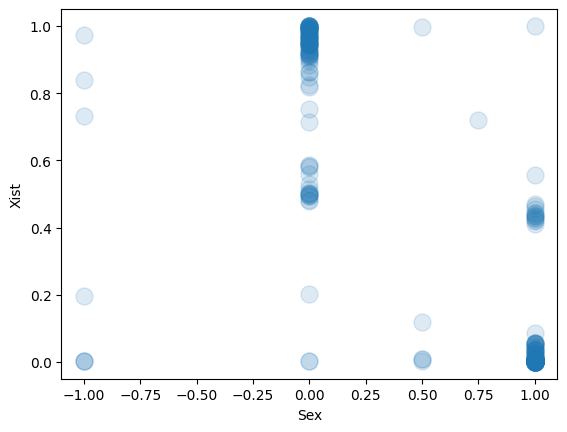

In [ ]:
#plot sex_numeric vs xist
import matplotlib.pyplot as plt
plt.scatter(sex, pct_xist,alpha=0.15,s=150)
plt.xlabel("Sex")
plt.ylabel("Xist")
plt.show()

# Train logistic regression model

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Convert lists to numpy arrays
sex = np.array(sex)
X = np.column_stack((pct_xist, pct_ddx3y, pct_kdm5d))

# Split data into known and unknown sex
#if sex is not 0 or 1, set it to -1
sex[(sex!=0) & (sex!=1)] = -1


known_indices = sex != -1
unknown_indices = sex == -1

X_known = X[known_indices]
y_known = sex[known_indices]
X_unknown = X[unknown_indices]

# Split known data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_known, y_known, test_size=0.3, random_state=42)

# Create and train the logistic regression model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# Evaluate the model
y_pred = model.predict(X_test)
print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Predict sex for unknown cases
unknown_predictions = model.predict(X_unknown)

# Print predictions for unknown cases
print("\nPredictions for Unknown Sex:")
for i, pred in enumerate(unknown_predictions):
    print(f"Sample {i+1}: {'Female' if pred == 0 else 'Male'}")

# If you want to update the original sex list with predictions
new_sex = sex.copy()
new_sex[unknown_indices] = unknown_predictions
print("\nUpdated sex list:")
print(new_sex)

Model Accuracy: 0.9523809523809523

Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      1.00      0.94        25
         1.0       1.00      0.92      0.96        38

    accuracy                           0.95        63
   macro avg       0.95      0.96      0.95        63
weighted avg       0.96      0.95      0.95        63


Predictions for Unknown Sex:
Sample 1: Male
Sample 2: Female
Sample 3: Male
Sample 4: Male
Sample 5: Female
Sample 6: Male
Sample 7: Female
Sample 8: Male
Sample 9: Male
Sample 10: Female
Sample 11: Male
Sample 12: Male
Sample 13: Female
Sample 14: Female
Sample 15: Female
Sample 16: Male
Sample 17: Male
Sample 18: Male
Sample 19: Male
Sample 20: Male
Sample 21: Male

Updated sex list:
[1. 0. 0. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 0. 1. 0.
 0. 0. 0. 0. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1.
 1. 0. 0. 0. 0. 0. 1. 1. 0. 0. 1. 1. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1

# Rerunning logistic regression model to find outliers

In [ ]:
# Evaluate on the entire dataset to check for mislabeling
all_predictions = model.predict(X)
mislabeled_indices = np.where((sex != -1) & (all_predictions != sex))[0]

print("\nPotentially Mislabeled Datapoints:")
if len(mislabeled_indices) > 0:
    for idx in mislabeled_indices:
        print(f"Index: {idx}, Original Label: {'Female' if sex[idx] == 0 else 'Male'}, "
              f"Predicted Label: {'Female' if all_predictions[idx] == 0 else 'Male'}")
        print(f"  Gene values: Xist={pct_xist[idx]:.4f}, DDX3Y={pct_ddx3y[idx]:.4f}, KDM5D={pct_kdm5d[idx]:.4f}")
else:
    print("No potentially mislabeled datapoints found.")

print(f"\nTotal number of potentially mislabeled datapoints: {len(mislabeled_indices)}")

#print sra ids
print("\nSRA IDs:")
for idx in mislabeled_indices:
    print(sra[idx])


Potentially Mislabeled Datapoints:
Index: 51, Original Label: Female, Predicted Label: Male
  Gene values: Xist=0.2025, DDX3Y=0.6234, KDM5D=0.2447
Index: 57, Original Label: Female, Predicted Label: Male
  Gene values: Xist=0.0028, DDX3Y=0.5281, KDM5D=0.1742
Index: 59, Original Label: Male, Predicted Label: Female
  Gene values: Xist=0.5554, DDX3Y=0.0054, KDM5D=0.0018
Index: 155, Original Label: Male, Predicted Label: Female
  Gene values: Xist=0.4651, DDX3Y=0.1695, KDM5D=0.2182
Index: 157, Original Label: Male, Predicted Label: Female
  Gene values: Xist=0.4555, DDX3Y=0.1779, KDM5D=0.2252
Index: 198, Original Label: Male, Predicted Label: Female
  Gene values: Xist=0.4689, DDX3Y=0.1701, KDM5D=0.2614
Index: 215, Original Label: Female, Predicted Label: Male
  Gene values: Xist=0.0039, DDX3Y=0.4333, KDM5D=0.3097
Index: 216, Original Label: Male, Predicted Label: Female
  Gene values: Xist=0.9989, DDX3Y=0.0006, KDM5D=0.0006

Total number of potentially mislabeled datapoints: 8

SRA IDs:

# Plotting Xist vs logistic regression score.

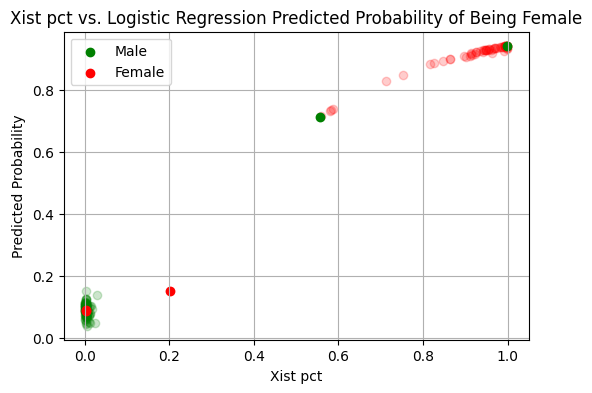

In [ ]:
y_pred_proba = model.predict_proba(X_known)[:, 1]
y_pred = model.predict(X_known)

# Extract pct_xist values for the test set
xist_pct_test = X[:, 0]

# Create a DataFrame for easier plotting
plot_df = pd.DataFrame({
    'xist_pct': np.array(pct_xist)[known_indices],
    'predicted_prob': 1-y_pred_proba,
    'real_value': y_known,
    'predicted_value': y_pred,
    'sra_id': np.array(sra)[known_indices],
})

#remove those where SRA_ID ends with _01
plot_df = plot_df[~plot_df['sra_id'].astype(str).str.endswith('_01')]

# Create a column for coloring based on prediction accuracy
plot_df['color'] = np.where(plot_df['real_value'] == 1, 'green', 'red')
plot_df['prediction_status'] = np.where(plot_df['real_value'] == 1, 'Male', 'Female')

# Create the scatter plot
plt.figure(figsize=(6, 4))

# Plot correct predictions in green
correct_df = plot_df[plot_df['prediction_status'] == 'Male']
plt.scatter(correct_df['xist_pct'], correct_df['predicted_prob'], color='green', alpha=0.2)

# Plot incorrect predictions in red
incorrect_df = plot_df[plot_df['prediction_status'] == 'Female']
plt.scatter(incorrect_df['xist_pct'], incorrect_df['predicted_prob'], color='red',alpha=0.2)

#keep where real value doesnt match predicted_value
mislabeled_df = plot_df[plot_df['real_value'] != plot_df['predicted_value']]
# Plot correct predictions in green
correct_df = mislabeled_df[mislabeled_df['prediction_status'] == 'Male']
plt.scatter(correct_df['xist_pct'], correct_df['predicted_prob'], color='green', label='Male',alpha=1)

# Plot incorrect predictions in red
incorrect_df = mislabeled_df[mislabeled_df['prediction_status'] == 'Female']
plt.scatter(incorrect_df['xist_pct'], incorrect_df['predicted_prob'], color='red', label='Female',alpha=1)

plt.title('Logistic Regression Predicted Probability of Being Female')
plt.xlabel('Xist pct.')
plt.ylabel('Predicted Probability')
plt.grid(True)
plt.legend()
# Save the plot
plt.savefig('xist_vs_logistic_regression_original.png')

# Generating the plot again with the corrected sexes

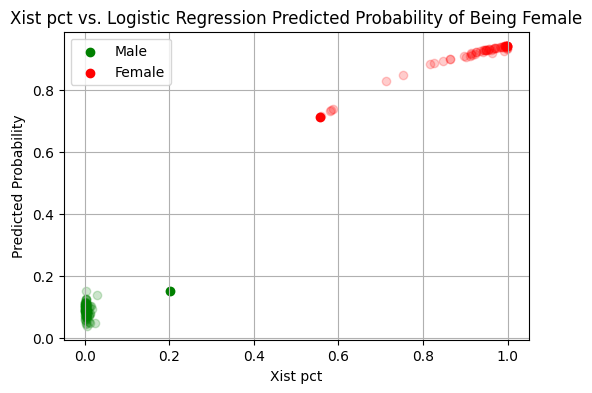

In [ ]:
y_pred_proba = model.predict_proba(X_known)[:, 1]
y_pred = model.predict(X_known)

# Extract pct_xist values for the test set
xist_pct_test = X[:, 0]

# Create a DataFrame for easier plotting
plot_df = pd.DataFrame({
    'xist_pct': np.array(pct_xist)[known_indices],
    'predicted_prob': 1-y_pred_proba,
    'real_value': y_known,
    'predicted_value': y_pred,
    'sra_id': np.array(sra)[known_indices],
})

#remove those where SRA_ID ends with _01
plot_df = plot_df[~plot_df['sra_id'].astype(str).str.endswith('_01')]

# Create a column for coloring based on prediction accuracy
plot_df['color'] = np.where(plot_df['predicted_value'] == 1, 'green', 'red')
plot_df['prediction_status'] = np.where(plot_df['predicted_value'] == 1, 'Male', 'Female')

# Create the scatter plot
plt.figure(figsize=(6, 4))

# Plot correct predictions in green
correct_df = plot_df[plot_df['prediction_status'] == 'Male']
plt.scatter(correct_df['xist_pct'], correct_df['predicted_prob'], color='green', alpha=0.2)

# Plot incorrect predictions in red
incorrect_df = plot_df[plot_df['prediction_status'] == 'Female']
plt.scatter(incorrect_df['xist_pct'], incorrect_df['predicted_prob'], color='red',alpha=0.2)

#keep where real value doesnt match predicted_value
mislabeled_df = plot_df[plot_df['real_value'] != plot_df['predicted_value']]
# Plot correct predictions in green
correct_df = mislabeled_df[mislabeled_df['prediction_status'] == 'Male']
plt.scatter(correct_df['xist_pct'], correct_df['predicted_prob'], color='green', label='Male',alpha=1)

# Plot incorrect predictions in red
incorrect_df = mislabeled_df[mislabeled_df['prediction_status'] == 'Female']
plt.scatter(incorrect_df['xist_pct'], incorrect_df['predicted_prob'], color='red', label='Female',alpha=1)

plt.title('Xist pct vs. Logistic Regression Predicted Probability of Being Female')
plt.xlabel('Xist pct')
plt.ylabel('Predicted Probability')
plt.grid(True)
plt.legend()
# Save the plot
plt.savefig('xist_vs_logistic_regression_corrected.png')


#Printing the 5 SRA_IDs with misannotated samples

In [ ]:
plot_df[plot_df["sra_id"].isin(["SRX21170825","SRX21986110","SRX21986112","SRX29174028","SRX29174029"])]

,xist_pct,predicted_prob,real_value,predicted_value,sra_id,color,prediction_status
47,0.202532,0.150509,0.0,1.0,SRX21170825,green,Male
53,0.002765,0.085211,0.0,1.0,SRX21986110,green,Male
55,0.555357,0.710437,1.0,0.0,SRX21986112,red,Female
202,0.003899,0.088787,0.0,1.0,SRX29174028,green,Male
203,0.998861,0.941567,1.0,0.0,SRX29174029,red,Female


In [ ]:
len(all_predictions)

229

# Adding new corrected sex values and saving back to the atlas spreadsheet

In [ ]:
#at least the first two of these, overwrite the sex values with predictions
new_sex[mislabeled_indices] = all_predictions[mislabeled_indices]

In [ ]:
#iterate through sra ids and add these vals back to df into column "Comp_sex"
df = pd.read_excel('/content/drive/MyDrive/pituitary_atlas/source_table/pituitary_atlas.xlsx')
for s in range(len(sra)):
  df.loc[df['SRA_ID'] == sra[s], 'Comp_sex'] = new_sex[s]
#save
df.to_excel('/content/drive/MyDrive/pituitary_atlas/source_table/pituitary_atlas.xlsx', index=False)

In [ ]:
#print subtable of values where Sex_numeric and Comp_sex differ
#show all rows
pd.set_option('display.max_rows', None)
sub_df = df[(df['Sex_numeric'] != df['Comp_sex'])]
#show SRA_ID, Sex_numeric and Comp_sex
sub_df = sub_df[['SRA_ID', 'Sex_numeric', 'Comp_sex']]
sub_df

,SRA_ID,Sex_numeric,Comp_sex
54,ERX7593481,0.50,1.0
55,ERX7593482,0.50,0.0
56,ERX7593483,0.50,1.0
57,ERX7593484,0.50,1.0
60,SRX21170825,0.00,1.0
66,SRX21986110,0.00,1.0
68,SRX21986112,1.00,0.0
98,SRX15581371,0.75,0.0
101,SRX8497092,-1.00,1.0
102,SRX8497093,-1.00,0.0


# ATAC-seq

In [ ]:
adata = sc.read("/content/drive/MyDrive/pituitary_atlas/Unstructured/pb_h5ad_2026_01_28.h5ad")

In [ ]:
y_tag = "chrY"
x_tag = "chrX"

adata.var["chrX"] = adata.var_names.str.startswith(x_tag)
adata.var["chrY"] = adata.var_names.str.startswith(y_tag)

sc.pp.calculate_qc_metrics(adata, qc_vars=["chrY","chrX"], inplace=True, percent_top=[20], log1p=True)
adata.obs

,sample,cell_type,Sex,_scvi_batch,_scvi_labels,Conditions,Author,Modality,GEO,psbulk_n_cells,...,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_20_genes,total_counts_chrY,log1p_total_counts_chrY,pct_counts_chrY,total_counts_chrX,log1p_total_counts_chrX,pct_counts_chrX
GSM4594382_Corticotrophs,GSM4594382,Corticotrophs,1.0,0,0,normal,Ruf-Zamojski et al. (2021),atac,GSM4594382,116.0,...,12.099205,1715443.0,14.355183,0.216387,86.0,4.465908,0.005013,29849.0,10.303940,1.740017
GSM4594385_Corticotrophs,GSM4594385,Corticotrophs,0.0,3,0,normal,Ruf-Zamojski et al. (2021),atac,GSM4594385,259.0,...,12.067356,2138869.0,14.575788,0.256117,0.0,0.000000,0.000000,38755.0,10.565041,1.811939
GSM4594386_Corticotrophs,GSM4594386,Corticotrophs,0.0,4,0,normal,Ruf-Zamojski et al. (2021),atac,GSM4594386,385.0,...,12.099411,1785188.0,14.395035,0.236390,0.0,0.000000,0.000000,31212.0,10.348590,1.748387
GSM4594387_Corticotrophs,GSM4594387,Corticotrophs,0.0,5,0,normal,Ruf-Zamojski et al. (2021),atac,GSM4594387,557.0,...,12.165350,2550936.0,14.751971,0.219488,0.0,0.000000,0.000000,46489.0,10.746992,1.822429
GSM4594388_Corticotrophs,GSM4594388,Corticotrophs,0.0,6,0,normal,Ruf-Zamojski et al. (2021),atac,GSM4594388,757.0,...,12.307211,5904416.0,15.591211,0.216025,0.0,0.000000,0.000000,105952.0,11.570751,1.794454
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM9301723_Thyrotrophs,GSM9301723,Thyrotrophs,1.0,42,0,Fshb-Enh2-KO,Jin et al. (2025),atac,GSM9301723,113.0,...,11.941912,848763.0,13.651536,0.298081,35.0,3.583519,0.004124,14071.0,9.551942,1.657824
GSM9301724_Thyrotrophs,GSM9301724,Thyrotrophs,1.0,43,0,IgG-treated,Jin et al. (2025),atac,GSM9301724,180.0,...,12.190197,1679595.0,14.334064,0.209634,50.0,3.931826,0.002977,27775.0,10.231928,1.653672
GSM9301725_Thyrotrophs,GSM9301725,Thyrotrophs,1.0,44,0,IgG-treated,Jin et al. (2025),atac,GSM9301725,106.0,...,12.036719,923346.0,13.735761,0.268372,33.0,3.526361,0.003574,14945.0,9.612199,1.618570
GSM9301727_Thyrotrophs,GSM9301727,Thyrotrophs,1.0,46,0,Bimagrumab-treated,Jin et al. (2025),atac,GSM9301727,152.0,...,12.101045,1223248.0,14.017021,0.238872,43.0,3.784190,0.003515,20020.0,9.904537,1.636626


/tmp/ipython-input-119545200.py:17: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs["Sex"] = adata.obs["Sex"].replace({"0.0": "Female", "1.0":  "Male"})
/tmp/ipython-input-119545200.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Files saved successfully as PNG and SVG.


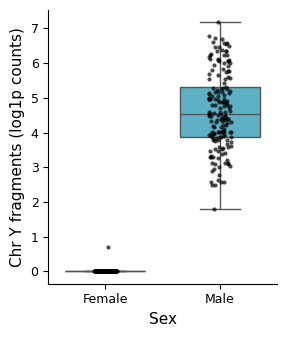

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

# 1. Set Nature-standard Typography
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']
rcParams['font.size'] = 11
rcParams['axes.titlesize'] = 11
rcParams['xtick.labelsize'] = 9
rcParams['ytick.labelsize'] = 9

# 2. Setup Figure
fig, ax = plt.subplots(figsize=(3, 3.5)) # Single column width ~89mm

#for sex change 0 to Female and 1.0 to Male
adata.obs["Sex"] = adata.obs["Sex"].replace({"0.0": "Female", "1.0":  "Male"})

# 3. Create the Plot
# Boxplot with properties matching Nature aesthetics (thin lines, no fliers)
sns.boxplot(
    x="Sex",
    y="log1p_total_counts_chrY",
    data=adata.obs,
    palette=["#E64B35", "#4DBBD5"],  # High-contrast, journal-style palette
    width=0.7,
    linewidth=1,
    fliersize=0,      # Hide outliers in boxplot because we'll show all points
    ax=ax
)

# Overlay individual points (Stripplot) for transparency
sns.stripplot(
    x="Sex",
    y="log1p_total_counts_chrY",
    data=adata.obs,
    color="black",
    size=3,
    alpha=0.7,
    jitter=True,
    ax=ax
)

# 4. Refine Axes and Spines
ax.set_xlabel("Sex")
ax.set_ylabel("Chr Y fragments (log1p counts)")
sns.despine() # Remove top and right borders

plt.tight_layout()

# Save for high-res presentations (300 DPI)
plt.savefig("/content/drive/MyDrive/pituitary_atlas/Unstructured/chrY_frags_plot.png", dpi=300, bbox_inches='tight')

# Save for publication submission (Scalable Vector Graphics)
plt.savefig("/content/drive/MyDrive/pituitary_atlas/Unstructured/chrY_frags_plot.svg", format='svg', bbox_inches='tight')

print("Files saved successfully as PNG and SVG.")

plt.show()

# Looks good, Male samples are indeed rich in Y chrom content and females are empty.



In [ ]:
!pip freeze

absl-py==1.4.0
absolufy-imports==0.3.1
accelerate==1.10.1
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.0
aiosignal==1.4.0
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.16.5
altair==5.5.0
anndata==0.12.2
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.11.0
anywidget==0.9.18
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array-api-compat==1.12.0
array_record==0.8.1
arrow==1.3.0
arviz==0.22.0
astropy==7.1.0
astropy-iers-data==0.2025.10.6.0.35.25
astunparse==1.6.3
atpublic==5.1
attrs==25.4.0
audioread==3.0.1
Authlib==1.6.5
autograd==1.8.0
babel==2.17.0
backcall==0.2.0
beartype==0.22.2
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.24.0
bigquery-magics==0.10.3
bleach==6.2.0
blinker==1.9.0
blis==1.3.0
blobfile==3.1.0
blosc2==3.10.0
bokeh==3.7.3
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
Brotli==1.1.0
build==1.3.0
CacheControl==0.14.3
cachetools==5.5.2
catalogue==2.0.10
certifi==2025.10.5
cffi==2.0.0
chardet==5.2.0
c